В этом блокноте с помощью аппроксимации экспериментальной кривой коэффициента отражения рассчитывается реальная и мнимая части диэлектрической проницаемости графеновых пленок разной толщины. Суть процедуры аппроксимации: 
1) по МНК или "вручную" найти угол резонанса по InSb, считая диэлектрическую проницаемость известной
2) найти сдвиг между экспериментальным и теоретическим минимумом InSb, сместить начало обеих осей x на это расстояние
3) аппроксимируя кривую графена по известному значению угла и сдвига, найти реальную и мнимую части д.п. графена


Вопросы:
1) Для МНК получается огромная погрешность д.п. Есть ли смысл повторно измерить? 
2) На теорвере матожидание отклонений точек было нулевое? Здесь очевидно, что это не так, можно ли оценивать доверительные интервалы по Фишеру? Независимы ли отклонения разных точек? Матрица ковариации - это и есть "доверительный" эллипсоид? 
3) учесть погрешность измерения в optimize curve ($\sigma$)
4) как вычисляется ковариация eps
5) некорректные обратные задачи?

Вопросы:
0) работают ли уравнения Максвелла для настолько тонких пленок
1) обоснование выбора участка суммирования: оценить влияние дифракции (систематическую погрешность), оптимальный отступ от границы; попробовать разные участки
2) учёт тензорного характера д.п. графена: яа) продольная и поперечная, б) вдоль толщины. Почему анизотропия только для плазмонов?
3) корректна ли аппроксимация, если резонанс сильно зависит от угла, который из-за дифракции определяется с точностью до десятых градуса; построить график ковариации от д.п., возможно есть смысл разобраться в алгоритмах optimize.curve()
4) по какому участку графика фитировать
5) почему ширина графиков InSb (и угол резонанса?) зависит от толщины графена (сдвиг может зависеть)
6) протестировать метод на InSb, одновременно фитировать его д.п., угол и сдвиг, сравнить д.п. с табличной;
7) протестировать 1 образец дважды, чтобы исключить случайную погрешность (помимо колебаний IMO, которые учтены нормировкой R)
8) какая ошибка в определении нуля гониометра и линейки?

Вопросы после доклада 17.11:
1) свойства образца: размер частиц, есть ли образец с другим размером
2) экспериментальная погрешность в статье photonics (5%??)
3) почему в photonics меньше дифракция?
4) можно расчитать угловое распределение и сделать поправку?
5) как устроен отсчёт нуля
6) почему диэлектрик при малом числе слоев; почему если Re>0, видим плазмоны 
7) роль InSb в распространении плазмона по графену; может ли идти плазмон в InSb если в графене Re>0 (работает ли условие разных знаков Re для трех слоев) и он тонкий (17 нм)
8) чистый PEDOT:PSS - будет ли ППР?
9) модель потери энергии (уширения), все ли входит в матрицы Френеля

Конспект по методам определения неопределенности (Вугрин)

1) Интервалы - общие (joint) или по одному параметру (предполагают независимость параметров)
2) The data itself may havesignificant uncertainties: there may be missing values,measurement error, systematic biases, etc. Nonlinear inverseproblems may involve discontinuities which result in mul-tiple values for the optimal parameters, due to complexitiesin the underlying physics (e.g., significant heterogeneities in material models). The parameters themselves may havesignificant variability as part of their inherent randomness.Finally, model form can also influence the parameter set-tings [Sun, 1999].
 
1. По линеаризации 

1) In linear models, the sum of
squares function is quadratic, and contours of constant sums
of squares are ellipses or ellipsoid surfaces. In nonlinear
models, if one approximates the nonlinear function with a
linear Taylor series expansion about the parameter estimate
^q, the sum of squares approximation is then quadratic.
2) Thus the confidence regions
computed with the linear approximation method may be
compromised by highly nonlinear models, small data sets,
or poor Hessian approximations.

#### NB У меня $R(\epsilon)$ = min в районе резонанса, а значит расчёт доверительного интервала по линейной модели может не работать? Посчитать гессиан символьно? 

2. По Фишеру:

1) Невязка $\leq$ const,  которая определяется по распределению Фишера
2) Гессиан не вычисляется

3. Логарифм.-макс.-правдоподобия тест

1) если ошибки нормально распределены, то сводится к МНК

In [2]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sympy

In [3]:
# Load data using configurable paths
# Output files are created in file aperture.ipynb

# Function to load data from file
def load_data(file_path):
    return pd.read_csv(file_path, sep='\t', decimal=',')

base_path = r'C:\Users\belco\Documents\Graphene\Data\Data_many_layers'

file_paths = {
    'data_3_5_along': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_along_3_5_full.ascii'),
    'data_3_5_trans': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_trans_3_5_full.ascii'),
    'data_6_along': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_along_6_full.ascii'),
    'data_6_trans': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_trans_6_full.ascii'),
    'data_12_along': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_along_12_full.ascii'),
    'data_12_trans': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_trans_12_full.ascii')
}

data_3_5_along = load_data(file_paths['data_3_5_along'])
data_3_5_trans = load_data(file_paths['data_3_5_trans'])
data_6_along = load_data(file_paths['data_6_along'])
data_6_trans = load_data(file_paths['data_6_trans'])
data_12_along = load_data(file_paths['data_12_along'])
data_12_trans = load_data(file_paths['data_12_trans'])

In [4]:
# Совет от GPT по обращению с глобальными переменными: ......

n_prism = complex(1.531, -0.002)                   # комплексный показатель преломления призмы Zeonex
eps_prism = n_prism**2                             # диэлектрическая проницаемость призмы Zeonex
eps_air = n = 1                                    # диэлектрическая проницаемость воздуха (1.00027717)
eps_InSb = complex(-17.3, 7.12)                    # InSb на 197мкм табличное значение
wavelength = 197 * 10**(-6)                        # длина волны лазера в метрах
d_layer = 35 * 10**(-9)                            # толщина графеновой плёнки в метрах
step = 0.083*10**(-6)                              # шаг в метрах 

# -18+0.0066j - InSb по Друде-Лоренцу
#  - графен 35 нм по Друде-Лоренцу
# - графен 35 нм из отчёта В.В.


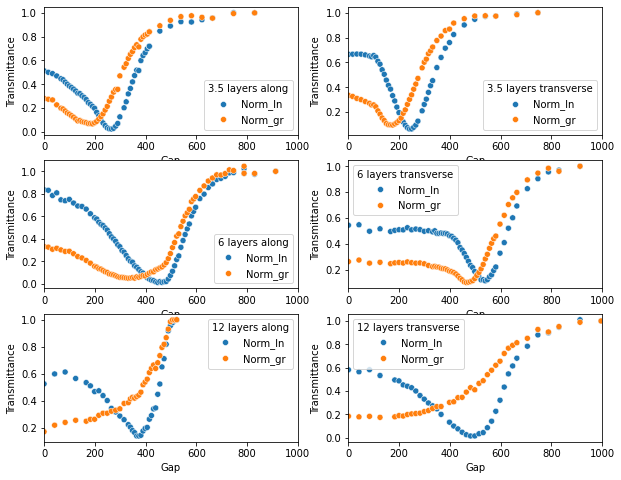

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8), ) 

al_3_5_melted = data_3_5_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers along', value_name='Transmittance')
sns.scatterplot(data = al_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers along", ax=axs[0, 0])
tr_3_5_melted = data_3_5_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers transverse", ax=axs[0, 1])
al_6_melted = data_6_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers along', value_name='Transmittance')
sns.scatterplot(data = al_6_melted, x="Gap", y="Transmittance", hue="6 layers along", ax=axs[1, 0])
tr_6_melted = data_6_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_6_melted, x="Gap", y="Transmittance", hue="6 layers transverse", ax=axs[1, 1])
al_12_melted = data_12_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers along', value_name='Transmittance')
sns.scatterplot(data = al_12_melted, x="Gap", y="Transmittance", hue="12 layers along", ax=axs[2, 0])
tr_12_melted = data_12_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_12_melted, x="Gap", y="Transmittance", hue="12 layers transverse", ax=axs[2, 1])
for ax in plt.gcf().axes:
    ax.set_xlim(0, 1000)
plt.show()

# изменить ось x


In [6]:
# Расчёт угла падения на внутреннюю грань на по углу падения пучка на внешние грани призмы
def teta_from_ext(teta_ext):
    teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))
    return teta

In [7]:
# define reflect3 by V.V.'s code


# d_2 - air gap, teta - internal incidence angle, eps_3 - permittivity of 3rd medium (InSb)
def reflect3(d_2, teta, eps3_re, eps3_im, wavelength = 197 * 10**(-6)):

    n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
    eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)       
    eps_2 = 1  # Dielectric permittivity of air
    eps_3 = eps3_re + eps3_im*1j
    
    # Normal components of wave vectors (normalized by k0)
    kz_1 = np.sqrt(eps_1) * np.cos(teta)
    kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
    kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)

    # Reflection coefficients
    r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)

    # Transmission coefficients
    t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)

    # Transformation matrix
    S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])

    R = np.zeros(len(d_2))  # Initialize reflection coefficient array

    for j in range(len(d_2)):
        S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                    [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]], dtype=np.complex128)
        
        S = np.dot(S1, S2)
        R[j] = (np.abs(S[1, 0] / S[0, 0]))**2

    return R

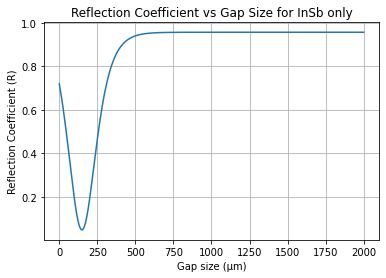

In [8]:
# Vizualize reflect3

d_2 = np.arange(0, 2000 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb
teta = 0.7334459774574046
eps3_re, eps3_im = (-16.999358675469676, 7.112859392867092)
params = [d_2, teta, eps3_re, eps3_im]
R = reflect3(*params)

# Plot the results
plt.plot(d_2 * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size for InSb only')
plt.grid()
plt.show()

In [9]:
# define reflect4 by V.V.'s code

def reflect4(d_2, d_3, teta, eps3_re, eps3_im, eps4_re, eps4_im, wavelength = 197 * 10**(-6)): # teta - internal incidence angle,  d_2 - gap, d_3 - Gr, eps_re/im - gr
    
    n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
    eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
    eps_2 = 1  #Dielectric permittivity of air"
    eps_3 = eps3_re+eps3_im*1j
    eps_4 = eps4_re+eps4_im*1j

    # Normal components of wave vectors (normalized by k0)
    kz_1 = np.sqrt(eps_1) * np.cos(teta)
    kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
    kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
    kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

    # Reflection coefficients
    r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transmission coefficients
    t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transformation matrices
    S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
    S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                    [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

    R = np.zeros(len(d_2))  # Initialize reflection coefficient array

    for j in range(len(d_2)):
        S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                        [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]], dtype=np.complex128)
        
        S = S1 @ S2 @ S3  # Matrix multiplication
        R[j] = (np.abs(S[1, 0] / S[0, 0]))**2
    
    return R


   

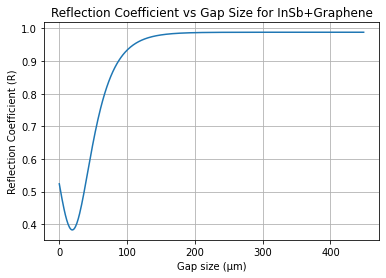

In [10]:
# Visualize reflect4

d_2 = np.arange(0, 450*10**(-6), 10**(-6))  # Gap size between the prism and InSb (microns)
d_3 = 35 * 10**(-9)  # Thickness of the studied layer 
teta = 0.8672552397697336
eps3_re, eps3_im = (-14, 700)

# Dielectric permittivity of the thin dielectric layer on InSb
eps4_re, eps4_im = (-16.999299592080213, 7.106286644764289)
R = reflect4(d_2, d_3, teta, eps3_re, eps3_im, eps4_re, eps4_im)

# Plot the results
plt.plot(d_2*10**(6), R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size for InSb+Graphene')
plt.grid()
plt.show()

[ 1.68040755e-04  7.35759925e-01 -8.81154447e+00  9.45696800e+00] [[ 1.04252842e-01 -5.78718477e-03  1.77789034e+04  5.77407923e+03]
 [-5.78718477e-03  3.22577164e-04 -9.86925788e+02 -3.20525645e+02]
 [ 1.77789034e+04 -9.86925788e+02  3.03195001e+09  9.84690630e+08]
 [ 5.77407923e+03 -3.20525645e+02  9.84690630e+08  3.19799348e+08]] {'nfev': 20, 'fvec': array([ 0.01405718,  0.0012119 , -0.00535776, -0.00602036, -0.00726847,
       -0.0045253 ,  0.00103518,  0.00408215,  0.01152052, -0.00655204,
        0.00824665,  0.0081661 , -0.00669311, -0.00105719, -0.00568986])} `xtol` termination condition is satisfied. 3
[ 1.49033181e-04  7.35759925e-01 -1.00643109e+01  1.30565930e+01] [[1.01748288e-01 5.38076104e-03 2.10818331e+04 1.09116217e+04]
 [5.38076104e-03 2.89395317e-04 1.11487084e+03 5.77037126e+02]
 [2.10818331e+04 1.11487084e+03 4.36807041e+09 2.26084382e+09]
 [1.09116217e+04 5.77037126e+02 2.26084382e+09 1.17017683e+09]] {'nfev': 18, 'fvec': array([-0.0220268 , -0.0144389 , -0.00978

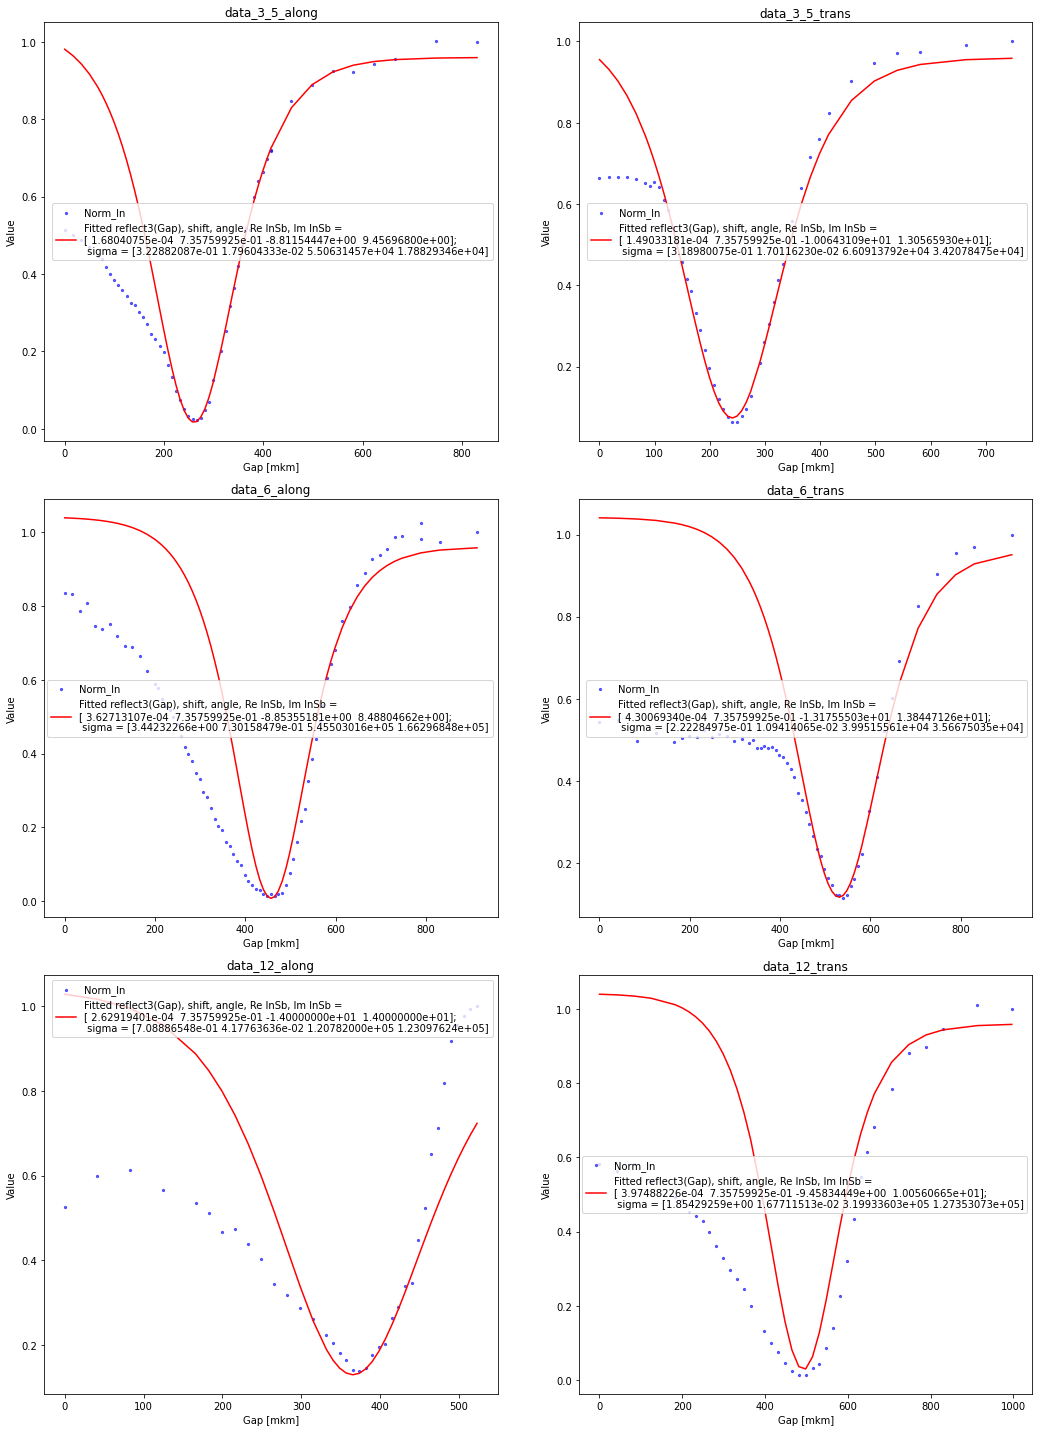

In [11]:
# подгонка угла, сдвига и (возможно) д.п. InSb по InSb
def fitting_function(x, shift, angle, re_InSb, im_InSb):
    return reflect3(x - np.ones(x.size, dtype=np.float64) * shift, angle, re_InSb, im_InSb)

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans, data_12_along, data_12_trans]

# Range of fitting (number of right/left points from minimum of R)
high_bound = 10
low_bound = 5

# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values.astype(np.float64) * 1e-6
    norm_in = df['Norm_In'].values.astype(np.float64)

    # Dynamic initial guesses based on data statistics
    shift_guess = 1e-6
    angle_guess = 7.35759925e-01  # Keeping as a constant guess, or adjust based on context
    re_InSb_guess = -9
    im_InSb_guess = 9
    initial_guess = [shift_guess, angle_guess, re_InSb_guess, im_InSb_guess]
    my_bounds = ([0, (7.35759925e-01)-(1e-10), -9-5, 9-5], [1e-3, (7.35759925e-01)+(1e-10), -9+5, 9+5])
    #([0, 1e-3],[0.6, 0.8], [-18, -16], [6, 8])


    # Ensure min_index and max_index are within bounds
    min_index = max(norm_in.argmin() - low_bound, 0)
    max_index = min(norm_in.argmin() + high_bound, len(gap))
    
    try:
        params, pcov , infodict , mesg, ier = curve_fit(fitting_function, 
                                                        gap[min_index:max_index], norm_in[min_index:max_index], 
          p0=initial_guess, bounds=my_bounds, method='trf', full_output=True)
        print(params, pcov , infodict , mesg , ier)
    except RuntimeError as e:
        print(f"Fitting failed for Dataframe {i+1}: {e}")
        params = initial_guess

    # Validate params before using them in the fitting function
    if not np.any(np.isnan(params)) and not np.any(np.isinf(params)):
        # Plot the original data
        axes[i].scatter(gap*1e6, norm_in, color='blue', label='Norm_In', s=5, alpha=0.6)

        # Plot the fitted function
        fitted_values = fitting_function(gap, *params)
        if not np.any(np.isnan(fitted_values)) and not np.any(np.isinf(fitted_values)):
            axes[i].plot(gap*1e6, fitted_values, color='red', 
                         label=f'Fitted reflect3(Gap), shift, angle, Re InSb, Im InSb = \n{params};\n sigma = {np.sqrt(np.diag(pcov))}', )
        else:
            print(f"Invalid fitted values for Dataframe {i+1}, skipping plot.")
    else:
        print(f"Invalid fitting parameters for Dataframe {i+1}, skipping plot.")

    # Set subplot title and labels
    titles = ['data_3_5_along', 'data_3_5_trans', 'data_6_along','data_6_trans', 'data_12_along', 'data_12_trans']
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Gap [mkm]')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()  



Отсюда находим угол резонанса  = 7.28050201e-01 - из 1 графика (3.5 слой along), т.к. на нём лучше аппроксимация.
На остальных графиках аппроксимация УЖАСНАЯ, хотя InSb графики должны СОВПАДАТЬ с точностью до сдвига
Причина уширения мне не ясна.



[ 3.54476596e-05 -1.15128376e+02  8.40445771e+01] [[2.68430288e-02 7.18386628e+04 9.74871049e+04]
 [7.18386628e+04 1.92258240e+11 2.60899890e+11]
 [9.74871049e+04 2.60899890e+11 3.54048558e+11]] {'nfev': 12, 'fvec': array([ 0.05229173,  0.02730591,  0.00733768, -0.00177483, -0.01267905,
       -0.01116195, -0.01585121, -0.0155215 , -0.01615568, -0.01127594,
       -0.00370028, -0.00059024,  0.00589339,  0.00262218,  0.00923652,
        0.01003883,  0.03005524,  0.06952171, -0.00380899, -0.00192464,
        0.00252796, -0.00985366, -0.01425849, -0.00934135, -0.01737562])} `gtol` termination condition is satisfied. 1
[ 2.53599689e-05 -1.06064979e+02  1.75567032e+02] [[1.23989945e-02 3.89206130e+04 5.65387307e+04]
 [3.89206130e+04 1.22172335e+11 1.77475847e+11]
 [5.65387307e+04 1.77475847e+11 2.57813492e+11]] {'nfev': 22, 'fvec': array([-0.02315104, -0.02325793, -0.01380998, -0.0123064 , -0.01239798,
       -0.00568365, -0.00225814,  0.00378553,  0.01213024,  0.01999434,
        0.0133855

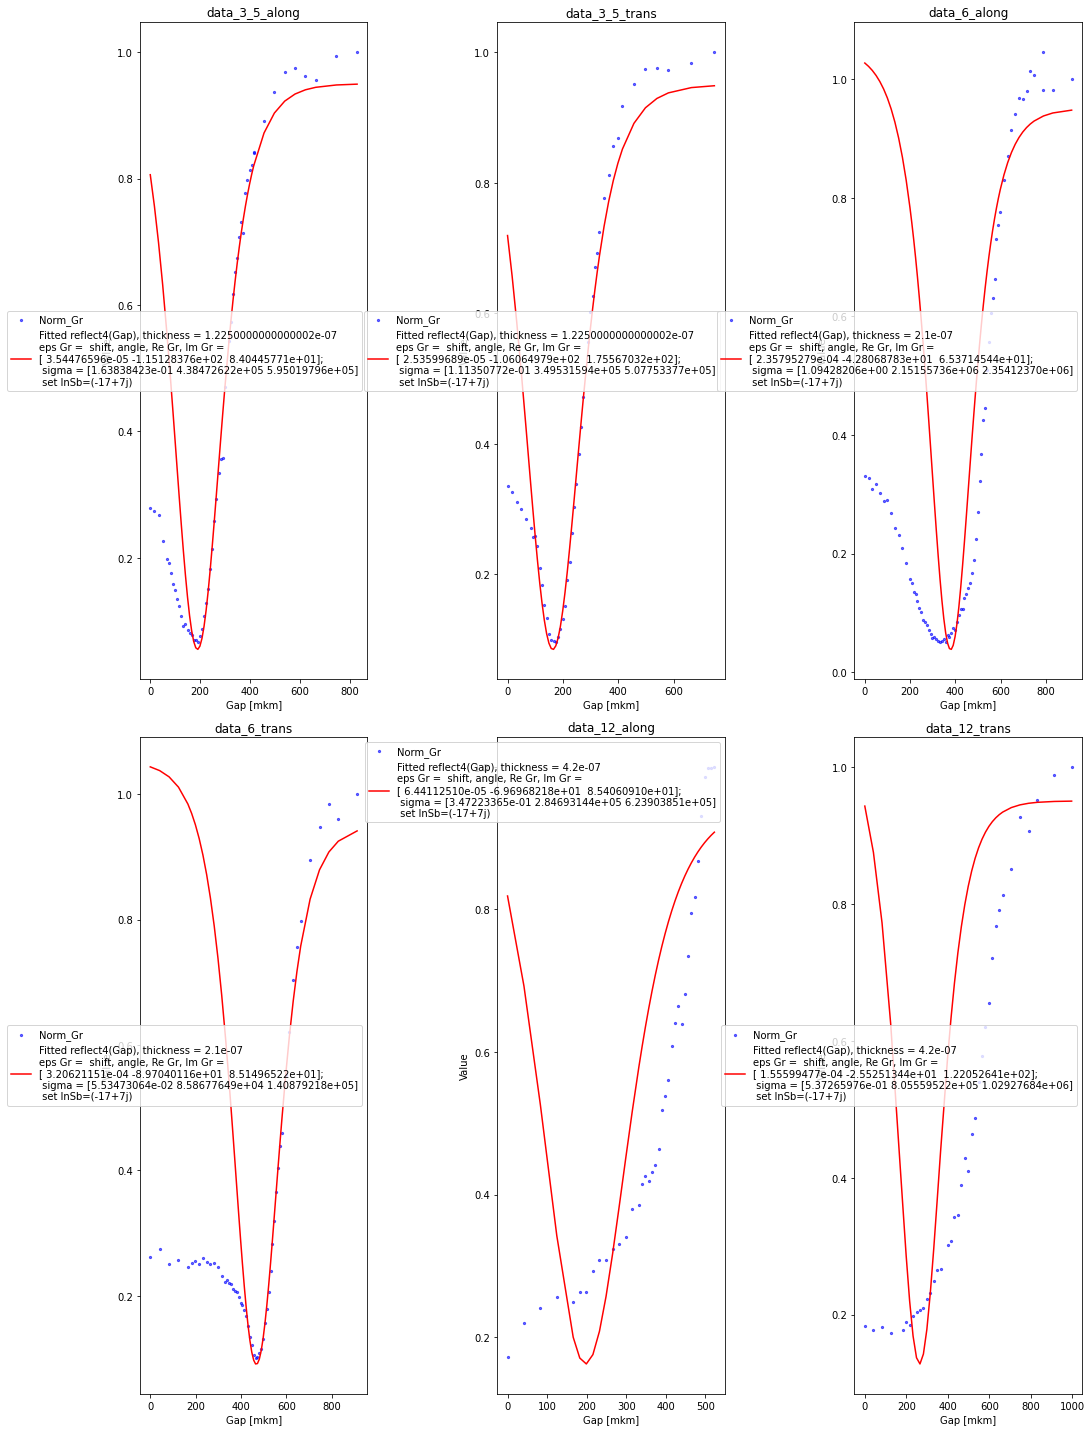

In [16]:
# Fitting permittivity of graphene

# угол из предыдущей подгонки по кривой InSb

# Set InSb for fitting
set_InSb = -17+7*1j

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans, data_12_along, data_12_trans]

# толщина слоёв
thickness = np.array([3.5, 3.5, 6, 6, 12, 12])*35e-9

# Range of fitting (number of right/left points from minimum of R)
high_bound = 20
low_bound = 5

# Create a figure for subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 20))
axes = axes.flatten()

re_fit_vec = np.zeros([6])
im_fit_vec = np.zeros([6])

for i, df in enumerate(dfs):
    gap = df['Gap'].values.astype(np.float64) * 1e-6
    norm_in = df['Norm_gr'].values.astype(np.float64)

    def fitting_function(x, shift, eps3_re, eps3_im):
        return reflect4(x - np.ones(x.size, dtype=np.float64) * shift, d_3 = thickness[i], 
                        teta = 7.28050201e-01, eps3_re=eps3_re, eps3_im=eps3_im, eps4_re=set_InSb.real, eps4_im=set_InSb.imag)

    # Dynamic initial guesses based on data statistics
    shift_guess = 1e-6
    re_Gr_guess = -9
    im_Gr_guess = 9
    initial_guess = [shift_guess, re_Gr_guess, im_Gr_guess]
    my_bounds = ([0,  -np.inf, 0], [1e-3, 0, np.inf])
    #([0, 1e-3],[0.6, 0.8], [-18, -16], [6, 8])


    # Ensure min_index and max_index are within bounds
    min_index = max(norm_in.argmin() - low_bound, 0)
    max_index = min(norm_in.argmin() + high_bound, len(gap))
    
    try:
        params, pcov , infodict , mesg , ier = curve_fit(fitting_function, 
                                                         gap[min_index:max_index], norm_in[min_index:max_index], 
                                                         p0=initial_guess, bounds=my_bounds, method='trf', full_output=True)
        print(params, pcov , infodict , mesg , ier)
    except RuntimeError as e:
        print(f"Fitting failed for Dataframe {i+1}: {e}")
        params = initial_guess

    # Validate params before using them in the fitting function
    if not np.any(np.isnan(params)) and not np.any(np.isinf(params)):
        # Plot the original data
        axes[i].scatter(gap*1e6, norm_in, color='blue', label='Norm_Gr', s=5, alpha=0.6)

        # Plot the fitted function
        fitted_values = fitting_function(gap, *params)
        if not np.any(np.isnan(fitted_values)) and not np.any(np.isinf(fitted_values)):
            axes[i].plot(gap*1e6, fitted_values, color='red', 
        #                label = 'fitting' 
                        label=f'Fitted reflect4(Gap), thickness = {thickness[i]}\neps Gr =  shift, angle, Re Gr, Im Gr =\n{params};\n sigma = {np.sqrt(np.diag(pcov))}\n set InSb={set_InSb}'
            ) 
        else:
            print(f"Invalid fitted values for Dataframe {i+1}, skipping plot.")
    else:
        print(f"Invalid fitting parameters for Dataframe {i+1}, skipping plot.")

    # Set subplot title and labels
    titles = ['data_3_5_along', 'data_3_5_trans', 'data_6_along','data_6_trans', 'data_12_along', 'data_12_trans']
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Gap [mkm]')
    axes[i].set_ylabel('Value')
    axes[i].legend()

    # Plot Re, Im vs thickness
    re_fit_vec[i] = params[1]
    im_fit_vec[i] = params[2]


# Adjust layout and show the plot



plt.tight_layout()
plt.show()  




Output for Graphene

[ 7.59362718e-05 -1.73652126e+01  1.54573263e+01] [[2.59352829e-02 7.33066619e+03 4.91923588e+03]
 [7.33066619e+03 2.07202933e+09 1.39043311e+09]
 [4.91923588e+03 1.39043311e+09 9.33048685e+08]] {'nfev': 22, 'fvec': array([ 0.05229159,  0.02730576,  0.00733751, -0.00177501, -0.01267923,
       -0.01116214, -0.01585139, -0.01552167, -0.01615583, -0.01127607,
       -0.00370039, -0.00059034,  0.00589332,  0.00262213,  0.00923649,
        0.01003882,  0.03005525,  0.06952173, -0.00380896, -0.00192459,
        0.00252801, -0.00985361, -0.01425843, -0.00934129, -0.01737556])} `xtol` termination condition is satisfied. 3
[ 4.25775050e-05 -2.12250555e+01  1.64058107e+01] [[1.25365843e-02 3.21931646e+03 2.80787185e+03]
 [3.21931646e+03 8.26700332e+08 7.21043930e+08]
 [2.80787185e+03 7.21043930e+08 6.28890940e+08]] {'nfev': 20, 'fvec': array([-0.02315103, -0.02325791, -0.01380996, -0.01230637, -0.01239795,
       -0.00568362, -0.0022581 ,  0.00378557,  0.01213028,  0.01999438,
        0.01338555,  0.02085058,  0.01390228,  0.01272569,  0.01552649,
        0.00913512,  0.00667343, -0.00063829, -0.01440939, -0.0265432 ,
       -0.02033539, -0.03504897, -0.02999889, -0.03588226, -0.04336887])} `xtol` termination condition is satisfied. 3
[ 3.15980176e-04 -2.62487872e-01  1.65719688e+01] [[1.17829890e+00 3.72083393e+05 2.12363172e+04]
 [3.72083393e+05 1.17496546e+11 6.70600723e+09]
 [2.12363172e+04 6.70600723e+09 3.82739233e+08]] {'nfev': 18, 'fvec': array([ 0.31454186,  0.27340489,  0.22653165,  0.18442761,  0.14421596,
        0.10639081,  0.06840841,  0.03471327,  0.01489626, -0.0138309 ,
       -0.01986846, -0.02807296, -0.02945204, -0.01135762, -0.00299288,
        0.01332764,  0.03607787,  0.07269322,  0.09528935,  0.13101791,
        0.16412761,  0.19972205,  0.22599972,  0.24660709,  0.25171041])} `ftol` termination condition is satisfied. 2
[ 3.70863925e-04 -1.20572135e+01  1.92281597e+01] [[3.08330941e-03 8.86461706e+02 4.10513890e+02]
 [8.86461706e+02 2.54860687e+08 1.18024108e+08]
 [4.10513890e+02 1.18024108e+08 5.46560958e+07]] {'nfev': 30, 'fvec': array([ 0.01471383,  0.0010112 , -0.00509819, -0.01155057, -0.00819774,
       -0.00933923, -0.01124167, -0.00892202, -0.00238645,  0.00064884,
        0.00045429,  0.0069914 ,  0.01175907,  0.01281741,  0.00734155,
        0.00981536,  0.00242355,  0.00207002,  0.00518737,  0.02174302,
       -0.00078658, -0.00595041, -0.03410087, -0.03848992, -0.03972996])} `xtol` termination condition is satisfied. 3
[ 9.08769658e-05 -1.47915856e+01  2.19336732e+01] [[1.20480373e-01 3.46017356e+04 1.90214378e+04]
 [3.46017356e+04 9.93755314e+09 5.46292099e+09]
 [1.90214378e+04 5.46292099e+09 3.00310410e+09]] {'nfev': 21, 'fvec': array([ 0.64732577,  0.47295517,  0.28579123,  0.08637141, -0.04917005,
       -0.09226727, -0.10121303, -0.11716258, -0.09984836, -0.0511567 ,
       -0.00622396,  0.05251959,  0.11031623,  0.13671901,  0.19320394,
        0.19368189,  0.20904292,  0.24150535,  0.25370996,  0.26606207])} `ftol` termination condition is satisfied. 2
[ 1.50921556e-04 -1.52573030e+01  1.87554441e+01] [[2.89455689e-01 7.05106294e+04 3.96008492e+04]
 [7.05106294e+04 1.71762002e+10 9.64666062e+09]
 [3.96008492e+04 9.64666062e+09 5.41784924e+09]] {'nfev': 34, 'fvec': array([ 7.58989065e-01,  6.97226636e-01,  5.89553271e-01,  4.51534070e-01,
        1.82788258e-01,  9.73188548e-02,  3.52530325e-02, -2.89399171e-02,
       -6.61407364e-02, -7.83506515e-02, -6.72741820e-02, -4.50028390e-02,
       -2.96680973e-04,  4.69913700e-02,  1.01528572e-01,  1.73025512e-01,
        2.72218574e-01,  3.25522114e-01,  3.41651710e-01,  3.83088290e-01,
        3.76483266e-01,  3.70302671e-01,  4.15567889e-01])} `xtol` termination condition is satisfied. 3


In [ ]:
thickness_ax = np.concatenate((np.array([0.5, 1])*35e-9, thickness[[0, 2, 4]]))*1e9
print(thickness_ax)
re_al_ax = np.concatenate([[256, -15], re_fit_vec[[0, 2, 4]]])
im_al_ax = np.concatenate([[268, 700], im_fit_vec[[0, 2, 4]]])
re_tr_ax = np.concatenate([[367, -15], re_fit_vec[[1, 3, 5]]])
im_tr_ax = np.concatenate([[465, 700], im_fit_vec[[1, 3, 5]]])
print(re_al_ax)

[ 17.5  35.  122.5 210.  420. ]
[ 256.          -15.         -115.12837619  -42.80687833  -69.6968218 ]


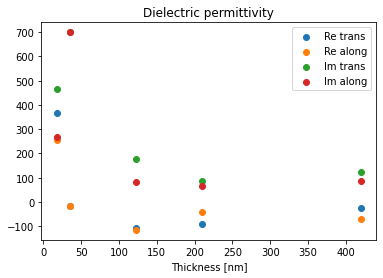

In [ ]:
# Plot Re, Im vs thickness

plt.scatter(thickness_ax, re_tr_ax, label = 'Re trans')
plt.scatter(thickness_ax, re_al_ax, label = 'Re along')
plt.scatter(thickness_ax, im_tr_ax, label = 'Im trans')
plt.scatter(thickness_ax, im_al_ax, label = 'Im along')

plt.xlabel('Thickness [nm]')
plt.title('Dielectric permittivity')
plt.legend()
plt.show()

In [ ]:
print(thickness_ax)
print(re_tr_ax)
print(re_al_ax)
print(im_tr_ax)
print(im_al_ax)
perm_to_csv = pd.DataFrame(np.array((thickness_ax, re_tr_ax, im_tr_ax, re_al_ax, im_al_ax)))
perm_to_csv.to_csv(sep = ';', decimal=',', lineterminator=' ')

[ 17.5  35.  122.5 210.  420. ]
[ 367.          -15.         -106.06497879  -89.70401155  -25.52513442]
[ 256.          -15.         -115.12837619  -42.80687833  -69.6968218 ]
[465.         700.         175.56703178  85.14965219 122.05264105]
[268.         700.          84.04457708  65.37145437  85.40609104]


';0;1;2;3;4 0;17,5;35,0;122,50000000000001;210,0;420,0 1;367,0;-15,0;-106,06497879326211;-89,70401155298795;-25,525134416450737 2;465,0;700,0;175,56703178256726;85,14965218899137;122,0526410470918 3;256,0;-15,0;-115,12837618603318;-42,80687832819221;-69,69682180163046 4;268,0;700,0;84,04457707860017;65,37145436936585;85,40609103580088 '

Попробуем разобраться с погрешностями $\epsilon$

Создадим тестовые данные с гауссовым шумом  

array([[3.71091216e-28, 1.01902652e-21, 1.42156500e-21],
       [1.01902652e-21, 2.79827444e-15, 3.90365598e-15],
       [1.42156500e-21, 3.90365598e-15, 5.44568824e-15]])

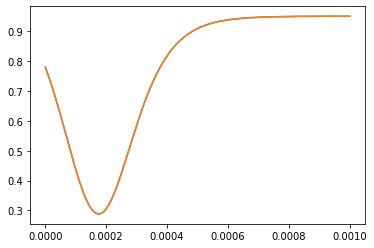

In [62]:
def create_data(x, shift, eps3_re, eps3_im):
        return reflect4(x - np.ones(x.size, dtype=np.float64) * shift, d_3 = thickness[i], 
          teta = 7.28050201e-01, eps3_re=eps3_re, eps3_im=eps3_im, eps4_re=-7, eps4_im=17)
_d = np.linspace(0, 1000*1e-6, 1000) 
data_noise = create_data(_d, 1e-4, -100, 170)+np.random.normal(0, 0, 1000)

__params, __pcov , infodict , mesg, ier = curve_fit(create_data, 
                                                        _d, data_noise, 
          p0=[1e-4, -95, 173], bounds = ([0.5*1e-4, -110, 160], [1.5e-4, -90, 180]),
 method='trf', full_output=True)
plt.plot(_d, data_noise)
plt.plot(_d, create_data(_d, *__params))
__params
__pcov


Мы видим, что даже без шума регрессия работает плохо